### Start by making sure you have your API key setup

In [48]:
import os

import numpy as np
import matplotlib.pyplot as plt
import copy

if os.getenv("A3_API_KEY", "") == "":
    os.environ["A3_API_KEY"] = "06682422"
    

### Do imports

In [3]:
import time
import rich

from cs336_scaling.client import (
    get_budget,
    get_experiment,
    list_experiments,
    save_final_submission,
    submit_experiment,
)
from cs336_scaling.training.model.basic_model import BasicTransformerConfig
from cs336_scaling.training.optimizer import AdamWConfig, WarmupCosineDecay
from cs336_scaling.training.training_config import TrainingConfig

/Users/alexgu/Code/cs336/cs336-a3/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 1. GetBudget

In [157]:
get_budget()

BudgetSummary(used_seconds=40215.39539695972, remaining_seconds=2984.6046030402795, total_budget_seconds=43200.0)

### 2. LR sweep to find LR scaling law

for a small model (~5M params) and a larger model (~40M params), sweep lr to find optimal LR, then use these two points to plot a LR scaling plot. 

In [ ]:
# small model
lr_small_base_config = {
    "architecture_config": {
        "attention_bias": False,
        "head_dim": 64,
        "hidden_size": 256,
        "intermediate_size": 688,        # ~8/3 × hidden_size
        "num_attention_heads": 4,
        "num_hidden_layers": 6,
        "num_key_value_heads": 4,        # full MHA
        "rms_norm_eps": 1e-6,
        "rope_theta": 1_000_000,
        "tie_word_embeddings": False,
        "dtype": "bfloat16",
        "vocab_size": 32_000,
    },
    "optimizer_config": {
        "lr_scheduler": {
            "peak_value": 3e-3,
            "final_lr_frac": 0.1,
            "warmup_frac": 0.01,
            "init_value": 0.0,
        },
        "weight_decay": 0.1,
        "beta1": 0.9,
        "beta2": 0.95,
        "eps": 1e-8,
        "eps_root": 1e-8,
        "grad_clip_norm": 1.0,
    },
    "train_batch_size": 128,             # 64K tokens/batch
    "val_batch_size": 64,
    "n_evals": 8,
    "total_train_tokens": 191 * 8 * 128 * 512,   # needs to divide 8 * 128 × 512, and since N is ~5M, we need 100M tokens for chinchilla ratio, so roughly 191 steps * 8 evals
    "max_runtime_seconds": 600.0,       # 10 min. first test run took 1 min, so 10 min is safe
    "model_seed": 67,
}
rich.print(lr_small_base_config)

{
    'architecture_config': {
        'attention_bias': False,
        'head_dim': 64,
        'hidden_size': 256,
        'intermediate_size': 688,
        'num_attention_heads': 4,
        'num_hidden_layers': 6,
        'num_key_value_heads': 4,
        'rms_norm_eps': 1e-06,
        'rope_theta': 1000000,
        'tie_word_embeddings': False,
        'dtype': 'bfloat16',
        'vocab_size': 32000
    },
    'optimizer_config': {
        'lr_scheduler': {'peak_value': 0.003, 'final_lr_frac': 0.1, 'warmup_frac': 0.01, 'init_value': 0.0},
        'weight_decay': 0.1,
        'beta1': 0.9,
        'beta2': 0.95,
        'eps': 1e-08,
        'eps_root': 1e-08,
        'grad_clip_norm': 1.0
    },
    'train_batch_size': 128,
    'val_batch_size': 64,
    'n_evals': 8,
    'total_train_tokens': 100139008,
    'max_runtime_seconds': 600.0,
    'model_seed': 67
}

In [ ]:
# LR sweep for small model
# lr_values = [3e-3] # test to see general runtime
lr_values = [3e-4, 1e-3, 3e-3, 1e-2, 3e-2]
for lr in lr_values:
    config = lr_small_base_config.copy()
    config["optimizer_config"]["lr_scheduler"]["peak_value"] = lr
    rich.print(config)
    submit_result = submit_experiment(config)
    submit_result


{
    'architecture_config': {
        'attention_bias': False,
        'head_dim': 64,
        'hidden_size': 256,
        'intermediate_size': 688,
        'num_attention_heads': 4,
        'num_hidden_layers': 6,
        'num_key_value_heads': 4,
        'rms_norm_eps': 1e-06,
        'rope_theta': 1000000,
        'tie_word_embeddings': False,
        'dtype': 'bfloat16',
        'vocab_size': 32000
    },
    'optimizer_config': {
        'lr_scheduler': {'peak_value': 0.0003, 'final_lr_frac': 0.1, 'warmup_frac': 0.01, 'init_value': 0.0},
        'weight_decay': 0.1,
        'beta1': 0.9,
        'beta2': 0.95,
        'eps': 1e-08,
        'eps_root': 1e-08,
        'grad_clip_norm': 1.0
    },
    'train_batch_size': 128,
    'val_batch_size': 64,
    'n_evals': 8,
    'total_train_tokens': 100139008,
    'max_runtime_seconds': 600.0,
    'model_seed': 67
}

{
    'architecture_config': {
        'attention_bias': False,
        'head_dim': 64,
        'hidden_size': 256,
        'intermediate_size': 688,
        'num_attention_heads': 4,
        'num_hidden_layers': 6,
        'num_key_value_heads': 4,
        'rms_norm_eps': 1e-06,
        'rope_theta': 1000000,
        'tie_word_embeddings': False,
        'dtype': 'bfloat16',
        'vocab_size': 32000
    },
    'optimizer_config': {
        'lr_scheduler': {'peak_value': 0.001, 'final_lr_frac': 0.1, 'warmup_frac': 0.01, 'init_value': 0.0},
        'weight_decay': 0.1,
        'beta1': 0.9,
        'beta2': 0.95,
        'eps': 1e-08,
        'eps_root': 1e-08,
        'grad_clip_norm': 1.0
    },
    'train_batch_size': 128,
    'val_batch_size': 64,
    'n_evals': 8,
    'total_train_tokens': 100139008,
    'max_runtime_seconds': 600.0,
    'model_seed': 67
}

{
    'architecture_config': {
        'attention_bias': False,
        'head_dim': 64,
        'hidden_size': 256,
        'intermediate_size': 688,
        'num_attention_heads': 4,
        'num_hidden_layers': 6,
        'num_key_value_heads': 4,
        'rms_norm_eps': 1e-06,
        'rope_theta': 1000000,
        'tie_word_embeddings': False,
        'dtype': 'bfloat16',
        'vocab_size': 32000
    },
    'optimizer_config': {
        'lr_scheduler': {'peak_value': 0.01, 'final_lr_frac': 0.1, 'warmup_frac': 0.01, 'init_value': 0.0},
        'weight_decay': 0.1,
        'beta1': 0.9,
        'beta2': 0.95,
        'eps': 1e-08,
        'eps_root': 1e-08,
        'grad_clip_norm': 1.0
    },
    'train_batch_size': 128,
    'val_batch_size': 64,
    'n_evals': 8,
    'total_train_tokens': 100139008,
    'max_runtime_seconds': 600.0,
    'model_seed': 67
}

{
    'architecture_config': {
        'attention_bias': False,
        'head_dim': 64,
        'hidden_size': 256,
        'intermediate_size': 688,
        'num_attention_heads': 4,
        'num_hidden_layers': 6,
        'num_key_value_heads': 4,
        'rms_norm_eps': 1e-06,
        'rope_theta': 1000000,
        'tie_word_embeddings': False,
        'dtype': 'bfloat16',
        'vocab_size': 32000
    },
    'optimizer_config': {
        'lr_scheduler': {'peak_value': 0.03, 'final_lr_frac': 0.1, 'warmup_frac': 0.01, 'init_value': 0.0},
        'weight_decay': 0.1,
        'beta1': 0.9,
        'beta2': 0.95,
        'eps': 1e-08,
        'eps_root': 1e-08,
        'grad_clip_norm': 1.0
    },
    'train_batch_size': 128,
    'val_batch_size': 64,
    'n_evals': 8,
    'total_train_tokens': 100139008,
    'max_runtime_seconds': 600.0,
    'model_seed': 67
}

In [21]:
rich.print(list_experiments())

[
    ExperimentResponse(
        experiment_id=924,
        training_config=TrainingConfig(
            architecture_config=BasicTransformerConfig(
                attention_bias=False,
                head_dim=64,
                hidden_size=256,
                intermediate_size=688,
                num_attention_heads=4,
                num_hidden_layers=6,
                num_key_value_heads=4,
                rms_norm_eps=1e-06,
                rope_theta=1000000,
                tie_word_embeddings=False,
                dtype='bfloat16',
                vocab_size=32000
            ),
            optimizer_config=AdamWConfig(
                lr_scheduler=WarmupCosineDecay(
                    peak_value=0.003,
                    final_lr_frac=0.1,
                    warmup_frac=0.01,
                    init_value=0.0
                ),
                weight_decay=0.1,
                beta1=0.9,
                beta2=0.95,
                eps=1e-08,
                eps_root=1e-08,
                grad_clip_norm=1.0
            ),
            train_batch_size=128,
            val_batch_size=64,
            n_evals=8,
            total_train_tokens=100139008,
            max_runtime_seconds=1800.0,
            model_seed=67
        ),
        status=CompletedExperimentStatus(
            queued_at=datetime.datetime(2026, 5, 5, 0, 12, 31, 593229, tzinfo=TzInfo(0)),
            dispatched_at=datetime.datetime(2026, 5, 5, 0, 12, 33, 173694, tzinfo=TzInfo(0)),
            run_id='fc-01KQTQNDCGM1SVQ31SRKC0JNY5',
            used_runtime_seconds=60.257176361978054,
            val_losses=[5.609375, 5.171875, 4.95703125, 4.828125, 4.73046875, 4.66796875, 4.63671875, 4.625],
            completed_at=datetime.datetime(2026, 5, 5, 0, 14, 26, 666318, tzinfo=TzInfo(0)),
            status_type='completed'
        )
    ),
    ExperimentResponse(
        experiment_id=928,
        training_config=TrainingConfig(
            architecture_config=BasicTransformerConfig(
                attention_bias=False,
                head_dim=64,
                hidden_size=256,
                intermediate_size=688,
                num_attention_heads=4,
                num_hidden_layers=6,
                num_key_value_heads=4,
                rms_norm_eps=1e-06,
                rope_theta=1000000,
                tie_word_embeddings=False,
                dtype='bfloat16',
                vocab_size=32000
            ),
            optimizer_config=AdamWConfig(
                lr_scheduler=WarmupCosineDecay(
                    peak_value=0.0003,
                    final_lr_frac=0.1,
                    warmup_frac=0.01,
                    init_value=0.0
                ),
                weight_decay=0.1,
                beta1=0.9,
                beta2=0.95,
                eps=1e-08,
                eps_root=1e-08,
                grad_clip_norm=1.0
            ),
            train_batch_size=128,
            val_batch_size=64,
            n_evals=8,
            total_train_tokens=100139008,
            max_runtime_seconds=600.0,
            model_seed=67
        ),
        status=CompletedExperimentStatus(
            queued_at=datetime.datetime(2026, 5, 5, 0, 18, 0, 676276, tzinfo=TzInfo(0)),
            dispatched_at=datetime.datetime(2026, 5, 5, 0, 18, 1, 527965, tzinfo=TzInfo(0)),
            run_id='fc-01KQTQZE14ZJ9HETNTE5HQ9T5Y',
            used_runtime_seconds=65.79295221099164,
            val_losses=[6.9453125, 6.609375, 6.45703125, 6.390625, 6.3671875, 6.359375, 6.35546875, 6.3515625],
            completed_at=datetime.datetime(2026, 5, 5, 0, 19, 42, 770008, tzinfo=TzInfo(0)),
            status_type='completed'
        )
    ),
    ExperimentResponse(
        experiment_id=929,
        training_config=TrainingConfig(
            architecture_config=BasicTransformerConfig(
                attention_bias=False,
                head_dim=64,
                hidden_size=256,
                intermediate_size=688,
               

In [78]:

lr_values = [3e-4, 1e-3, 3e-3, 1e-2, 3e-2]
val_losses = [6.3515625, 5.3203125, 4.625, 4.375, 4.51953125]


In [27]:
# larger model LR sweep
lr_large_base_config = {
    "architecture_config": {
        "attention_bias": False,
        "head_dim": 64,
        "hidden_size": 512,
        "intermediate_size": 1376,        # ~8/3 × 512, rounded to mult. of 32
        "num_attention_heads": 8,         # 512 / 64
        "num_hidden_layers": 12,          # keeps aspect ratio ≈ 43, same as small
        "num_key_value_heads": 8,         # full MHA
        "rms_norm_eps": 1e-6,
        "rope_theta": 1_000_000,
        "tie_word_embeddings": False,
        "dtype": "bfloat16",
        "vocab_size": 32_000,
    },
    "optimizer_config": {
        "lr_scheduler": {
            "peak_value": 7e-3,           # 1e-2 × sqrt(256/512), based on formula from Vaswani et al.
            "final_lr_frac": 0.1,
            "warmup_frac": 0.01,
            "init_value": 0.0,
        },
        "weight_decay": 0.1,
        "beta1": 0.9,
        "beta2": 0.95,
        "eps": 1e-8,
        "eps_root": 1e-8,
        "grad_clip_norm": 1.0,
    },
    "train_batch_size": 128,              # match small for LR comparison
    "val_batch_size": 64,
    "n_evals": 8,
    "total_train_tokens": 1440 * 8 * 128 * 512,  # ~755M, D/N ≈ 20 (Chinchilla)
    "max_runtime_seconds": 3000.0,        # 50 min — generous for first run
    "model_seed": 67,
}
rich.print(lr_large_base_config)

{
    'architecture_config': {
        'attention_bias': False,
        'head_dim': 64,
        'hidden_size': 512,
        'intermediate_size': 1376,
        'num_attention_heads': 8,
        'num_hidden_layers': 12,
        'num_key_value_heads': 8,
        'rms_norm_eps': 1e-06,
        'rope_theta': 1000000,
        'tie_word_embeddings': False,
        'dtype': 'bfloat16',
        'vocab_size': 32000
    },
    'optimizer_config': {
        'lr_scheduler': {'peak_value': 0.007, 'final_lr_frac': 0.1, 'warmup_frac': 0.01, 'init_value': 0.0},
        'weight_decay': 0.1,
        'beta1': 0.9,
        'beta2': 0.95,
        'eps': 1e-08,
        'eps_root': 1e-08,
        'grad_clip_norm': 1.0
    },
    'train_batch_size': 128,
    'val_batch_size': 64,
    'n_evals': 8,
    'total_train_tokens': 754974720,
    'max_runtime_seconds': 3000.0,
    'model_seed': 67
}

In [39]:
# LR sweep for larger model
# lr_values = [7e-3] # test to see general runtime
lr_values = [4e-3, 1.5e-2]
for lr in lr_values:
    config = lr_large_base_config.copy()
    config["optimizer_config"]["lr_scheduler"]["peak_value"] = lr
    rich.print(config)
    submit_result = submit_experiment(config)
    submit_result


{
    'architecture_config': {
        'attention_bias': False,
        'head_dim': 64,
        'hidden_size': 512,
        'intermediate_size': 1376,
        'num_attention_heads': 8,
        'num_hidden_layers': 12,
        'num_key_value_heads': 8,
        'rms_norm_eps': 1e-06,
        'rope_theta': 1000000,
        'tie_word_embeddings': False,
        'dtype': 'bfloat16',
        'vocab_size': 32000
    },
    'optimizer_config': {
        'lr_scheduler': {'peak_value': 0.004, 'final_lr_frac': 0.1, 'warmup_frac': 0.01, 'init_value': 0.0},
        'weight_decay': 0.1,
        'beta1': 0.9,
        'beta2': 0.95,
        'eps': 1e-08,
        'eps_root': 1e-08,
        'grad_clip_norm': 1.0
    },
    'train_batch_size': 128,
    'val_batch_size': 64,
    'n_evals': 8,
    'total_train_tokens': 754974720,
    'max_runtime_seconds': 3000.0,
    'model_seed': 67
}

{
    'architecture_config': {
        'attention_bias': False,
        'head_dim': 64,
        'hidden_size': 512,
        'intermediate_size': 1376,
        'num_attention_heads': 8,
        'num_hidden_layers': 12,
        'num_key_value_heads': 8,
        'rms_norm_eps': 1e-06,
        'rope_theta': 1000000,
        'tie_word_embeddings': False,
        'dtype': 'bfloat16',
        'vocab_size': 32000
    },
    'optimizer_config': {
        'lr_scheduler': {'peak_value': 0.015, 'final_lr_frac': 0.1, 'warmup_frac': 0.01, 'init_value': 0.0},
        'weight_decay': 0.1,
        'beta1': 0.9,
        'beta2': 0.95,
        'eps': 1e-08,
        'eps_root': 1e-08,
        'grad_clip_norm': 1.0
    },
    'train_batch_size': 128,
    'val_batch_size': 64,
    'n_evals': 8,
    'total_train_tokens': 754974720,
    'max_runtime_seconds': 3000.0,
    'model_seed': 67
}

In [42]:
rich.print(list_experiments())

[
    ExperimentResponse(
        experiment_id=924,
        training_config=TrainingConfig(
            architecture_config=BasicTransformerConfig(
                attention_bias=False,
                head_dim=64,
                hidden_size=256,
                intermediate_size=688,
                num_attention_heads=4,
                num_hidden_layers=6,
                num_key_value_heads=4,
                rms_norm_eps=1e-06,
                rope_theta=1000000,
                tie_word_embeddings=False,
                dtype='bfloat16',
                vocab_size=32000
            ),
            optimizer_config=AdamWConfig(
                lr_scheduler=WarmupCosineDecay(
                    peak_value=0.003,
                    final_lr_frac=0.1,
                    warmup_frac=0.01,
                    init_value=0.0
                ),
                weight_decay=0.1,
                beta1=0.9,
                beta2=0.95,
                eps=1e-08,
                eps_root=1e-08,
                grad_clip_norm=1.0
            ),
            train_batch_size=128,
            val_batch_size=64,
            n_evals=8,
            total_train_tokens=100139008,
            max_runtime_seconds=1800.0,
            model_seed=67
        ),
        status=CompletedExperimentStatus(
            queued_at=datetime.datetime(2026, 5, 5, 0, 12, 31, 593229, tzinfo=TzInfo(0)),
            dispatched_at=datetime.datetime(2026, 5, 5, 0, 12, 33, 173694, tzinfo=TzInfo(0)),
            run_id='fc-01KQTQNDCGM1SVQ31SRKC0JNY5',
            used_runtime_seconds=60.257176361978054,
            val_losses=[5.609375, 5.171875, 4.95703125, 4.828125, 4.73046875, 4.66796875, 4.63671875, 4.625],
            completed_at=datetime.datetime(2026, 5, 5, 0, 14, 26, 666318, tzinfo=TzInfo(0)),
            status_type='completed'
        )
    ),
    ExperimentResponse(
        experiment_id=928,
        training_config=TrainingConfig(
            architecture_config=BasicTransformerConfig(
                attention_bias=False,
                head_dim=64,
                hidden_size=256,
                intermediate_size=688,
                num_attention_heads=4,
                num_hidden_layers=6,
                num_key_value_heads=4,
                rms_norm_eps=1e-06,
                rope_theta=1000000,
                tie_word_embeddings=False,
                dtype='bfloat16',
                vocab_size=32000
            ),
            optimizer_config=AdamWConfig(
                lr_scheduler=WarmupCosineDecay(
                    peak_value=0.0003,
                    final_lr_frac=0.1,
                    warmup_frac=0.01,
                    init_value=0.0
                ),
                weight_decay=0.1,
                beta1=0.9,
                beta2=0.95,
                eps=1e-08,
                eps_root=1e-08,
                grad_clip_norm=1.0
            ),
            train_batch_size=128,
            val_batch_size=64,
            n_evals=8,
            total_train_tokens=100139008,
            max_runtime_seconds=600.0,
            model_seed=67
        ),
        status=CompletedExperimentStatus(
            queued_at=datetime.datetime(2026, 5, 5, 0, 18, 0, 676276, tzinfo=TzInfo(0)),
            dispatched_at=datetime.datetime(2026, 5, 5, 0, 18, 1, 527965, tzinfo=TzInfo(0)),
            run_id='fc-01KQTQZE14ZJ9HETNTE5HQ9T5Y',
            used_runtime_seconds=65.79295221099164,
            val_losses=[6.9453125, 6.609375, 6.45703125, 6.390625, 6.3671875, 6.359375, 6.35546875, 6.3515625],
            completed_at=datetime.datetime(2026, 5, 5, 0, 19, 42, 770008, tzinfo=TzInfo(0)),
            status_type='completed'
        )
    ),
    ExperimentResponse(
        experiment_id=929,
        training_config=TrainingConfig(
            architecture_config=BasicTransformerConfig(
                attention_bias=False,
                head_dim=64,
                hidden_size=256,
                intermediate_size=688,
               

K ≈ 0.140
α ≈ -0.172


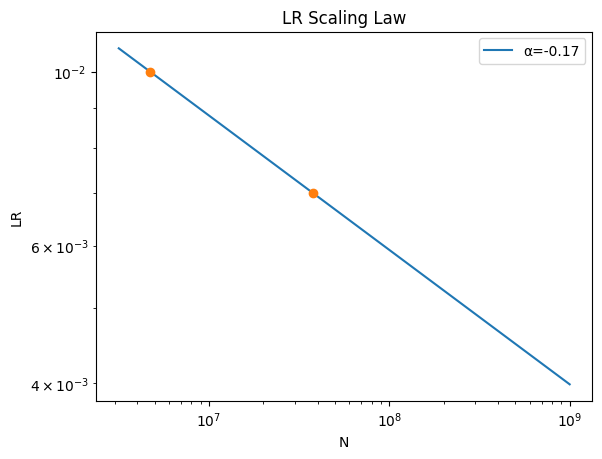

In [45]:
# Peak LR for small: 1e-2
# Peak LR for large: 7e-3
# LR scaling law plot

N1, N2 = 4.72e6, 37.75e6
LR1, LR2 = 1e-2, 7e-3

alpha = np.log(LR2/LR1) / np.log(N2/N1)

K = LR1 / N1**alpha

print(f"K ≈ {K:.3f}")
print(f"α ≈ {alpha:.3f}")

Ns = np.array([N1, N2])
lrs = np.array([LR1, LR2])

alpha, logK = np.polyfit(np.log(Ns), np.log(lrs), 1)
K = np.exp(logK)

N_plot = np.logspace(6.5, 9, 100)
plt.loglog(N_plot, K * N_plot**alpha, label=f'α={alpha:.2f}')
plt.loglog(Ns, lrs, 'o')
plt.xlabel('N')
plt.ylabel('LR')
plt.legend()
plt.title('LR Scaling Law')
plt.show()


## 3. IsoFLOPs grid

In [ ]:
def lr_from_N(N):
    return 0.14 * N ** -0.172

def make_arch(N_target, head_dim=64, aspect_ratio=43):
    """Pick (hidden_size, n_layers) hitting ~N_target non-embed params."""
    # Solve 12 * (d/aspect) * d^2 = N_target  ->  d^3 = N_target * aspect / 12
    d_ideal = (N_target * aspect_ratio / 12) ** (1/3)
    d = round(d_ideal / head_dim) * head_dim # snap to head_dim
    n_layers = max(2, round(d / aspect_ratio)) # snap to integer
    num_heads = d // head_dim
    intermediate = round(8 * d / 3 / 32) * 32                 # 8/3 ratio, mult. of 32
    N_actual = 12 * n_layers * d**2
    return {
        "hidden_size": d,
        "num_hidden_layers": n_layers,
        "num_attention_heads": num_heads,
        "num_key_value_heads": num_heads,
        "head_dim": head_dim,
        "intermediate_size": intermediate,
        "_N_actual": N_actual,
    }

def make_grid_point(compute_budget, d_n_ratio): 
    # C = 6N(rN)
    N_target = (compute_budget / (6*d_n_ratio)) ** (1/2)
    arch = make_arch(N_target)
    D_ideal = compute_budget / (arch["_N_actual"] * 6)
    divisor = 128 * 512 * 8
    D_actual = max(divisor, round(D_ideal / divisor) * divisor) # round to nearest multiple of divisor so training doesn't error
    return arch, D_actual

# ratios centered on chinchilla ratio
# My large run was 2e17 FLOPs, which took roughly 20 minutes, so 1e18 will take at most 100 minutes ~ 1.5h assuming same MFU. 
GRID = {
    1e17: [5, 10, 20, 80],         # <1 hr
    3e17: [5, 10, 20, 40, 80],         # <3 hr
    1e18: [5, 10, 20, 40],         # <7 hr
}

In [142]:
budget = 3e17
ratios = [20]
param_sizes = []

for ratio in ratios:
    arch, d = make_grid_point(budget, ratio)
    config = copy.deepcopy(lr_large_base_config)
    n = arch["_N_actual"]
    param_sizes.append(n)
    # arch
    config["architecture_config"]["hidden_size"]         = arch["hidden_size"]
    config["architecture_config"]["intermediate_size"]   = arch["intermediate_size"]
    config["architecture_config"]["num_attention_heads"] = arch["num_attention_heads"]
    config["architecture_config"]["num_hidden_layers"]   = arch["num_hidden_layers"]
    config["architecture_config"]["num_key_value_heads"] = arch["num_key_value_heads"]
    config["architecture_config"]["head_dim"]            = arch["head_dim"]
    
    # lr from fitted power law
    config["optimizer_config"]["lr_scheduler"]["peak_value"] = lr_from_N(n)
    
    # data
    config["total_train_tokens"] = d
    
    # Runtime cap — generous (2× estimate), tighten on subsequent submissions
    config["max_runtime_seconds"] = 40*60
    config["model_seed"] = 69
    rich.print(config)
    submit_result = submit_experiment(config)

print(param_sizes)


{
    'architecture_config': {
        'attention_bias': False,
        'head_dim': 64,
        'hidden_size': 576,
        'intermediate_size': 1536,
        'num_attention_heads': 9,
        'num_hidden_layers': 13,
        'num_key_value_heads': 9,
        'rms_norm_eps': 1e-06,
        'rope_theta': 1000000,
        'tie_word_embeddings': False,
        'dtype': 'bfloat16',
        'vocab_size': 32000
    },
    'optimizer_config': {
        'lr_scheduler': {
            'peak_value': 0.006596677769767334,
            'final_lr_frac': 0.1,
            'warmup_frac': 0.01,
            'init_value': 0.0
        },
        'weight_decay': 0.1,
        'beta1': 0.9,
        'beta2': 0.95,
        'eps': 1e-08,
        'eps_root': 1e-08,
        'grad_clip_norm': 1.0
    },
    'train_batch_size': 128,
    'val_batch_size': 64,
    'n_evals': 8,
    'total_train_tokens': 966262784,
    'max_runtime_seconds': 2400,
    'model_seed': 69
}

[51757056]


C=1e+17: N*=29874445.38208471 D*=557890413 D/N=18.7 L*=3.5982
C=3e+17: N*=71651477.49105735 D*=697822316 D/N=9.7 L*=3.4552
C=1e+18: N*=111446175.94244333 D*=1495490224 D/N=13.4 L*=3.3349


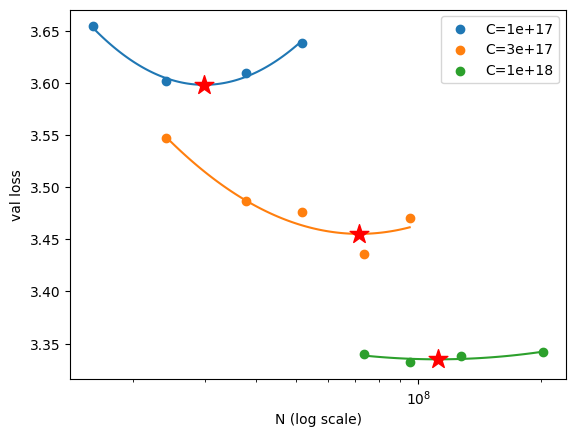

In [151]:
data = {1e17: {"parameters": [51757056, 37748736, 24084480, 15925248], "validation_losses": [3.638671875, 3.609375, 3.6015625, 3.654296875]},
3e17: {"parameters": [95158272, 73728000, 51757056, 37748736, 24084480], "validation_losses": [3.470703125, 3.435546875, 3.4765625, 3.486328125, 3.546875]},
1e18: {"parameters": [202309632, 127401984, 95158272, 73728000], "validation_losses": [3.341796875, 3.337890625, 3.33203125, 3.33984375]}}

for C, d in data.items():
    Ns = np.array(d["parameters"])
    losses = np.array(d["validation_losses"])
    log_N = np.log(Ns)
    a, b, c = np.polyfit(log_N, losses, 2)
    N_star = np.exp(-b / (2*a))
    L_star = a*np.log(N_star)**2 + b*np.log(N_star) + c
    D_star = C / (6 * N_star)
    print(f"C={C:.0e}: N*={N_star} D*={D_star:.0f} D/N={D_star/N_star:.1f} L*={L_star:.4f}")

    plt.scatter(Ns, losses, label=f"C={C:.0e}")
    N_plot = np.exp(np.linspace(log_N.min(), log_N.max(), 100))
    plt.plot(N_plot, a*np.log(N_plot)**2 + b*np.log(N_plot) + c)
    plt.scatter([N_star], [L_star], marker='*', s=200, color='red', zorder=5)

plt.xscale('log')
plt.xlabel('N (log scale)')
plt.ylabel('val loss')
plt.legend()
plt.show()

In [217]:
from scipy.optimize import curve_fit

compute_budgets    = np.array([1e17, 3e17, 1e18])
optimal_parameters = np.array([29874445, 71651477, 111446176])
optimal_data       = np.array([557890413, 697822316, 1495490224])
optimal_loss       = np.array([3.5982, 3.4552, 3.3349])

def param_power_law(c, a, b):
    return a * c**b

def data_power_law(c, a, b):
    return a * c**b

def loss_chinchilla(c, E, B, beta):
    return E + B * c**(-beta)

param_popt, _ = curve_fit(param_power_law, compute_budgets, optimal_parameters, maxfev=10000)
data_popt,  _ = curve_fit(data_power_law,  compute_budgets, optimal_data,       maxfev=10000)
loss_popt,  _ = curve_fit(loss_chinchilla, compute_budgets, optimal_loss,
                          p0=[2.5, 1.0, 0.05], maxfev=10000)

def r2(y, pred):
    return 1 - np.sum((y - pred)**2) / np.sum((y - y.mean())**2)

print(f"Params fit (a, b): {param_popt}, R² = {r2(optimal_parameters, param_power_law(compute_budgets, *param_popt)):.4f}")
print(f"Data fit   (a, b): {data_popt}, R² = {r2(optimal_data,       data_power_law(compute_budgets,  *data_popt)):.4f}")
print(f"Loss fit (E, B, β): {loss_popt}, R² = {r2(optimal_loss,       loss_chinchilla(compute_budgets, *loss_popt)):.4f}")

Params fit (a, b): [0.21402591 0.48472637], R² = 0.9619
Data fit   (a, b): [1.38324879 0.50143676], R² = 0.9593
Loss fit (E, B, β): [2.95812713e+00 5.23330354e+03 2.30149794e-01], R² = 1.0000


/var/folders/fh/rpmzxf95481_p4gk19kxfgfw0000gn/T/ipykernel_71462/810743560.py:19: OptimizeWarning: Covariance of the parameters could not be estimated
  loss_popt,  _ = curve_fit(loss_chinchilla, compute_budgets, optimal_loss,


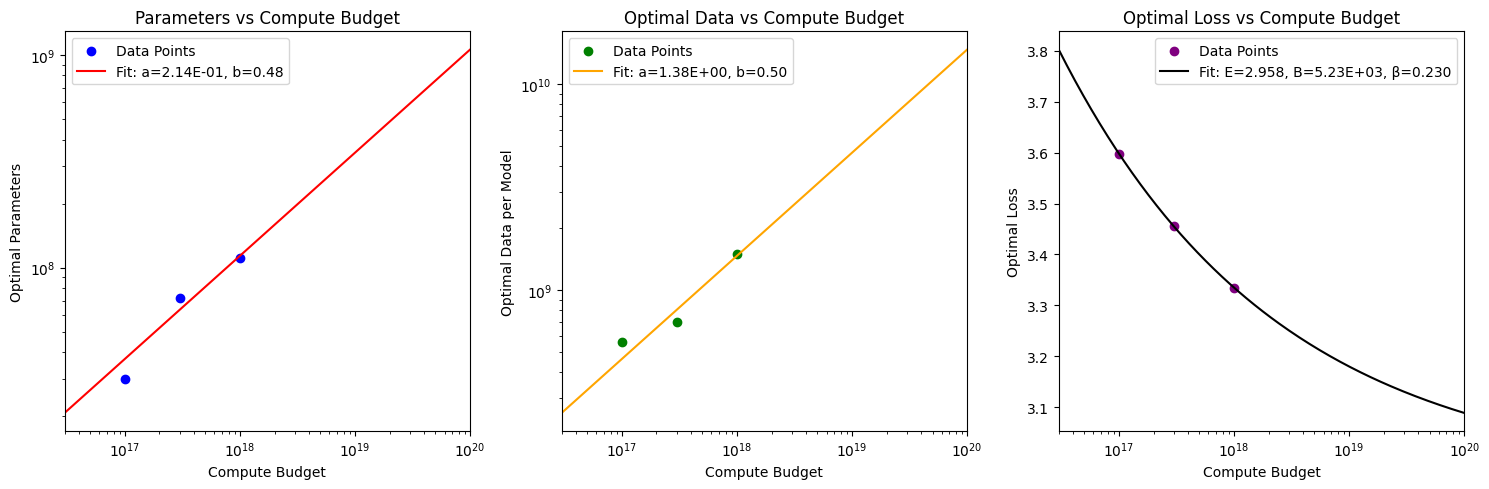

In [169]:
plt.figure(figsize=(15, 5))

xmin = 3e16
xmax = 1e20
x_fit = np.logspace(np.log10(xmin), np.log10(xmax), 200)

plt.subplot(1, 3, 1)
plt.scatter(compute_budgets, optimal_parameters, label='Data Points', color='blue')
y_fit = param_power_law(x_fit, *param_popt)
plt.plot(x_fit, y_fit, label=f'Fit: a={param_popt[0]:.2E}, b={param_popt[1]:.2f}', color='red')
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Compute Budget")
plt.ylabel("Optimal Parameters")
plt.title("Parameters vs Compute Budget")
plt.xlim(xmin, xmax)
plt.legend()

plt.subplot(1, 3, 2)
plt.scatter(compute_budgets, optimal_data, label='Data Points', color='green')
y_fit = data_power_law(x_fit, *data_popt)
plt.plot(x_fit, y_fit, label=f'Fit: a={data_popt[0]:.2E}, b={data_popt[1]:.2f}', color='orange')
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Compute Budget")
plt.ylabel("Optimal Data per Model")
plt.title("Optimal Data vs Compute Budget")
plt.xlim(xmin, xmax)
plt.legend()

plt.subplot(1, 3, 3)
plt.scatter(compute_budgets, optimal_loss, label='Data Points', color='purple')
y_fit = loss_chinchilla(x_fit, *loss_popt)
plt.plot(x_fit, y_fit,
         label=f'Fit: E={loss_popt[0]:.3f}, B={loss_popt[1]:.2E}, β={loss_popt[2]:.3f}',
         color='black')
plt.xscale('log')
plt.xlabel("Compute Budget")
plt.ylabel("Optimal Loss")
plt.title("Optimal Loss vs Compute Budget")
plt.xlim(xmin, xmax)
plt.legend()

plt.tight_layout()
plt.show()

## 4. Runtime analysis

In [188]:
Ns = []
runtimes = []
Ds = []  

for exp in list_experiments():
    arch = exp.training_config.architecture_config
    params = 12 * arch.num_hidden_layers * arch.hidden_size**2
    if params > 1e7: #ignore small models
        Ns.append(params)
        runtimes.append(exp.status.used_runtime_seconds)
        Ds.append(exp.training_config.total_train_tokens)

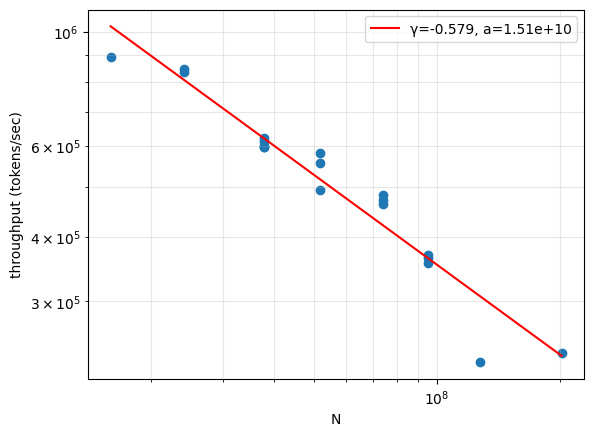

throughput(N) ≈ 1.51e+10 * N^-0.579


In [189]:
Ns_arr = np.array(Ns)
throughputs = np.array(Ds) / np.array(runtimes)

# fit power law in log-log
gamma, log_a = np.polyfit(np.log(Ns_arr), np.log(throughputs), 1)
a = np.exp(log_a)

N_plot = np.logspace(np.log10(Ns_arr.min()), np.log10(Ns_arr.max()), 100)
plt.scatter(Ns_arr, throughputs)
plt.plot(N_plot, a * N_plot**gamma, 'r-', label=f'γ={gamma:.3f}, a={a:.2e}')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('N')
plt.ylabel('throughput (tokens/sec)')
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.show()

print(f"throughput(N) ≈ {a:.2e} * N^{gamma:.3f}")

## 5. Select optimal training for 48 b200hrs

In [ ]:
# Throughput fit
a_t     = 1.51e+10
gamma_t = -0.579

# Scaling law fits
b_N = 0.485
a_N = 0.214 

b_D = 0.501
a_D = 1.383

T_budget = 48 * 60 * 60

# solve for C
power      = b_D - b_N * gamma_t
prefactor  = a_D / (a_t * a_N**gamma_t)
C_opt      = (T_budget / prefactor) ** (1 / power)

N_opt      = a_N * C_opt ** b_N
D_opt      = a_D * C_opt ** b_D

runtime_check = D_opt / (a_t * N_opt**gamma_t)
print(f"C* = {C_opt:.3e}")
print(f"N* = {N_opt/1e6:.1f}M")
print(f"D* = {D_opt/1e9:.2f}B")
print(f"D/N = {D_opt/N_opt:.1f}")
print(f"runtime check: {runtime_check/3600:.2f} hr")

C* = 1.083e+20
N* = 1114.9M
D* = 15.07B
D/N = 13.5
runtime check: 48.00 hr


In [196]:
arch = make_arch(N_opt)
N_actual = arch["_N_actual"]
print(N_actual)

1136640000


In [197]:
#iterate through potential N nearby to see if any other candidates.
MAX_RUNTIME = 48 * 60 * 60

for N_target in range(int(1e9), int(1.5e9), int(1e8)):
    arch = make_arch(N_target)
    N_actual = arch["_N_actual"]
    throughput = a_t * N_actual ** gamma_t
    D_possible = MAX_RUNTIME * throughput
    print(f"N={N_actual}, D={D_possible}")
    print(f"d/r ratio: {D_possible / N_actual}")


N=1019215872, D=15875761585.315872
d/r ratio: 15.576446581589217
N=1136640000, D=14904417444.493452
d/r ratio: 13.112698342917241
N=1136640000, D=14904417444.493452
d/r ratio: 13.112698342917241
N=1295843328, D=13815060453.216991
d/r ratio: 10.661057671639291
N=1433272320, D=13031858634.198374
d/r ratio: 9.092381435370477


In [211]:
N_opt_actual = 1136640000
D_opt_actual = 14904417445
D_opt_actual_rounded = (round(D_opt_actual / (8 * 512 * 128) + 1)) * (8 * 512 * 128)
C_opt_actual = D_opt_actual_rounded * N_opt_actual * 6
print(f"C* = {C_opt_actual:.3e}")

C* = 1.016e+20


In [207]:
runtime_check = D_opt_actual_rounded / (a_t * N_opt_actual**gamma_t)
print(f"runtime check: {runtime_check/3600:.2f} hr")

runtime check: 48.00 hr


In [215]:
#predicted val loss
loss_predicted = loss_chinchilla(C_opt_actual, *loss_popt)
print(f"predicted val loss: {loss_predicted:.4f}")

predicted val loss: 3.0882


In [208]:
arch = make_arch(N_opt_actual)
d = D_opt_actual_rounded
config = copy.deepcopy(lr_large_base_config)
n = arch["_N_actual"]
param_sizes.append(n)
# arch
config["architecture_config"]["hidden_size"]         = arch["hidden_size"]
config["architecture_config"]["intermediate_size"]   = arch["intermediate_size"]
config["architecture_config"]["num_attention_heads"] = arch["num_attention_heads"]
config["architecture_config"]["num_hidden_layers"]   = arch["num_hidden_layers"]
config["architecture_config"]["num_key_value_heads"] = arch["num_key_value_heads"]
config["architecture_config"]["head_dim"]            = arch["head_dim"]

# lr from fitted power law
config["optimizer_config"]["lr_scheduler"]["peak_value"] = lr_from_N(n)

# data
config["total_train_tokens"] = d

# Runtime cap — generous (2× estimate), tighten on subsequent submissions
config["max_runtime_seconds"] = 48*60*60
config["model_seed"] = 67
rich.print(config)


{
    'architecture_config': {
        'attention_bias': False,
        'head_dim': 64,
        'hidden_size': 1600,
        'intermediate_size': 4256,
        'num_attention_heads': 25,
        'num_hidden_layers': 37,
        'num_key_value_heads': 25,
        'rms_norm_eps': 1e-06,
        'rope_theta': 1000000,
        'tie_word_embeddings': False,
        'dtype': 'bfloat16',
        'vocab_size': 32000
    },
    'optimizer_config': {
        'lr_scheduler': {
            'peak_value': 0.0038775811079582757,
            'final_lr_frac': 0.1,
            'warmup_frac': 0.01,
            'init_value': 0.0
        },
        'weight_decay': 0.1,
        'beta1': 0.9,
        'beta2': 0.95,
        'eps': 1e-08,
        'eps_root': 1e-08,
        'grad_clip_norm': 1.0
    },
    'train_batch_size': 128,
    'val_batch_size': 64,
    'n_evals': 8,
    'total_train_tokens': 14904983552,
    'max_runtime_seconds': 172800,
    'model_seed': 67
}

### Submit your final validation. This will run for 48 B200-hours

In [213]:
rich.print(save_final_submission(config, loss_predicted))

FinalSubmissionResponse(
    training_config=TrainingConfig(
        architecture_config=BasicTransformerConfig(
            attention_bias=False,
            head_dim=64,
            hidden_size=1600,
            intermediate_size=4256,
            num_attention_heads=25,
            num_hidden_layers=37,
            num_key_value_heads=25,
            rms_norm_eps=1e-06,
            rope_theta=1000000,
            tie_word_embeddings=False,
            dtype='bfloat16',
            vocab_size=32000
        ),
        optimizer_config=AdamWConfig(
            lr_scheduler=WarmupCosineDecay(
                peak_value=0.0038775811079582757,
                final_lr_frac=0.1,
                warmup_frac=0.01,
                init_value=0.0
            ),
            weight_decay=0.1,
            beta1=0.9,
            beta2=0.95,
            eps=1e-08,
            eps_root=1e-08,
            grad_clip_norm=1.0
        ),
        train_batch_size=128,
        val_batch_size=64,
        n_evals=8,
        total_train_tokens=14904983552,
        max_runtime_seconds=172800.0,
        model_seed=67
    ),
    predicted_final_loss=3.0881874004990904,
    submitted_at=datetime.datetime(2026, 5, 5, 22, 32, 9, 817113, tzinfo=TzInfo(0))
)